In [22]:
import zipfile
import os

with zipfile.ZipFile("wine+quality.zip", "r") as zip_ref:
    zip_ref.extractall("wine_data")

print("Dataset extracted successfully!")
print(os.listdir("wine_data"))

Dataset extracted successfully!
['winequality-white.csv', 'winequality-red.csv', 'winequality.names']


In [23]:
import pandas as pd

data = pd.read_csv("wine_data/winequality-red.csv", sep=";")

print("Dataset loaded successfully!")
print(data.head())
print("Shape:", data.shape)

Dataset loaded successfully!
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8   

In [24]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nDataset Information:")
data.info()

Dataset Shape: (1599, 12)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non

In [25]:
print("Missing Values in Each Column:")
print(data.isnull().sum())

Missing Values in Each Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [26]:
X = data.drop("quality", axis=1)
y = data["quality"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1599, 11)
Target shape: (1599,)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")
print("Scaled data shape:", X_scaled.shape)

Data standardized successfully!
Scaled data shape: (1599, 11)


In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed successfully!")
print("First 20 cluster labels:")
print(clusters[:20])

K-Means clustering completed successfully!
First 20 cluster labels:
[3 3 3 5 3 3 3 3 3 4 3 4 3 1 4 4 4 1 3 1]


In [29]:
print("Number of wines in each cluster:")

for cluster in range(6):
    count = (clusters == cluster).sum()
    print("Cluster", cluster, ":", count)

Number of wines in each cluster:
Cluster 0 : 34
Cluster 1 : 30
Cluster 2 : 302
Cluster 3 : 533
Cluster 4 : 338
Cluster 5 : 362


In [30]:
import numpy as np

cluster_to_quality = {}

for cluster in np.unique(clusters):
    quality_values = y[clusters == cluster]
    majority_quality = quality_values.mode()[0]
    cluster_to_quality[cluster] = majority_quality

print("Cluster to Quality Mapping:")
print(cluster_to_quality)

Cluster to Quality Mapping:
{np.int32(0): np.int64(5), np.int32(1): np.int64(5), np.int32(2): np.int64(6), np.int32(3): np.int64(5), np.int32(4): np.int64(5), np.int32(5): np.int64(6)}


In [31]:
y_pred = np.array([
    cluster_to_quality[cluster]
    for cluster in clusters
])

print("Actual Quality:")
print(y.values[:20])

print("\nPredicted Quality:")
print(y_pred[:20])

Actual Quality:
[5 5 5 6 5 5 5 7 7 5 5 5 5 5 5 5 7 5 4 6]

Predicted Quality:
[5 5 5 6 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]


In [32]:
import numpy as np

cluster_to_quality = {}

for cluster in np.unique(clusters):
    quality_values = y[clusters == cluster]
    majority_quality = quality_values.mode()[0]
    cluster_to_quality[cluster] = majority_quality

print("Cluster to Quality Mapping:")
print(cluster_to_quality)

Cluster to Quality Mapping:
{np.int32(0): np.int64(5), np.int32(1): np.int64(5), np.int32(2): np.int64(6), np.int32(3): np.int64(5), np.int32(4): np.int64(5), np.int32(5): np.int64(6)}


In [33]:
y_pred = np.array([
    cluster_to_quality[cluster]
    for cluster in clusters
])

print("Predictions created successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions created successfully!
First 20 predictions:
[5 5 5 6 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]


In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.5503439649781113
Accuracy Percentage: 55.03 %


In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  0   0   8   2   0   0]
 [  0   0  45   8   0   0]
 [  0   0 542 139   0   0]
 [  0   0 300 338   0   0]
 [  0   0  39 160   0   0]
 [  0   0   1  17   0   0]]


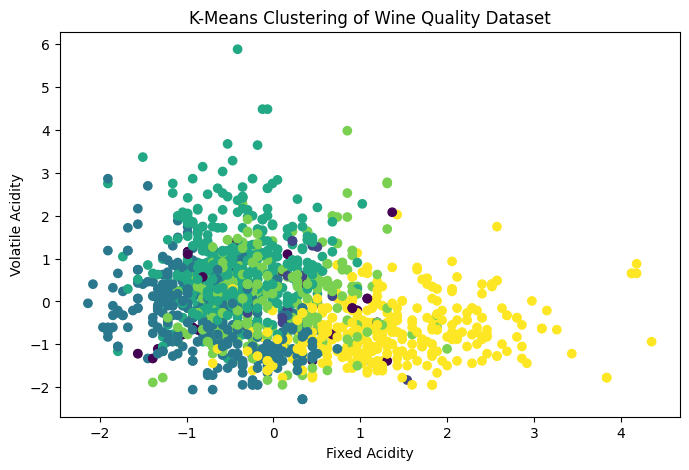

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters
)

plt.xlabel("Fixed Acidity")
plt.ylabel("Volatile Acidity")
plt.title("K-Means Clustering of Wine Quality Dataset")
plt.show()

In [37]:
print("=" * 50)
print("FINAL RESULT")
print("=" * 50)
print("Dataset: Wine Quality (UCI)")
print("Algorithm: K-Means Clustering")
print("Number of Clusters:", 6)
print("Accuracy:", round(accuracy * 100, 2), "%")

FINAL RESULT
Dataset: Wine Quality (UCI)
Algorithm: K-Means Clustering
Number of Clusters: 6
Accuracy: 55.03 %
